In [9]:
from functools import partial
from mc_core.sampling.exponential import *
from mc_core.utils.montecarlo import *
from matplotlib import pyplot as plt
from mc_core.utils.randomVariable import *
import scipy.stats as scistats
import matplotlib

## Exponential Distribution

## Direct Sampling

In [10]:
num_samples = 10000
lambda_parameter = 2
exponential_samples = sample_exponential(lambda_parameter, num_samples)

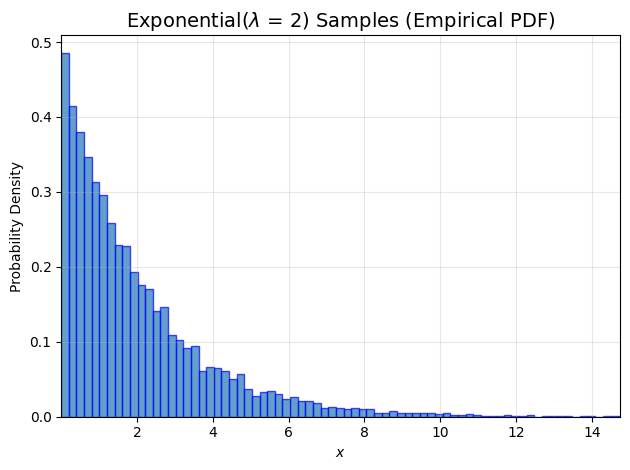

In [11]:
visualize_samples(exponential_samples, "Exponential($\lambda$ = 2)")

## Empirical vs Theoretical Distribution

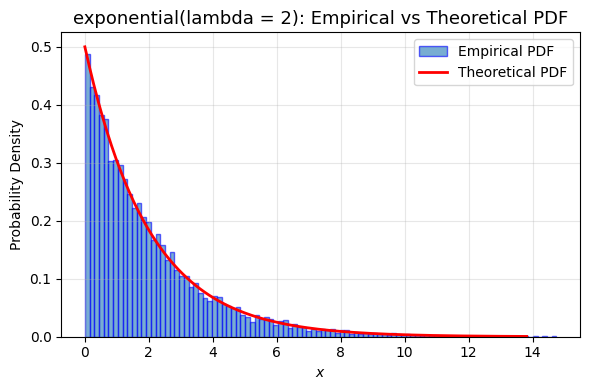

In [12]:
expon_rv = scistats.expon(scale=lambda_parameter)
plot_empirical_and_theoretical_pdf(exponential_samples,expon_rv,dist_name=f"exponential(lambda = {lambda_parameter})")

## Running Monte Carlo Estimate of the Mean (Law of Large Numbers)

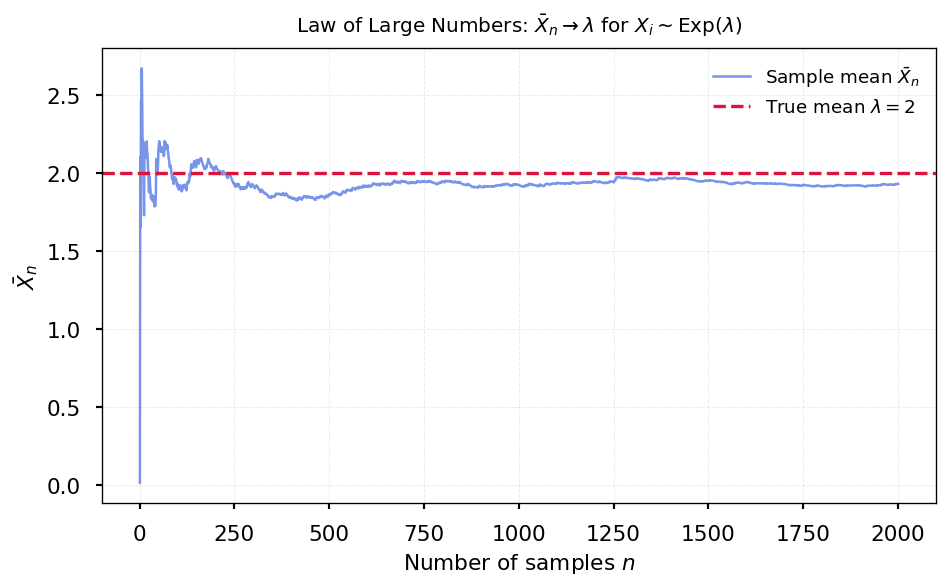

In [46]:
exp_gen = partial(sample_exponential, 2)
mc_exp = monte_carlo(2000, exp_gen, lambda x: x, cumsum=True)
nsample_arr = nsample_arr = np.arange(1, mc_exp.estimate.shape[0] + 1) # an array of numbers form 1,2,...,nsamples

# Plot
plt.figure(figsize=(8, 5), dpi=120)
plt.plot(nsample_arr, mc_exp.estimate, color='royalblue', lw=1.5, alpha=0.7, label=r'Sample mean $\bar{X}_n$')
plt.axhline(y=2, color='crimson', lw=2.0, linestyle='--', label=r'True mean $\lambda=2$')


# Labels & title
plt.xlabel(r'Number of samples $n$', fontsize=13)
plt.ylabel(r'$\bar{X}_n$', fontsize=13)
plt.title(r'Law of Large Numbers: $\bar{X}_n \rightarrow \lambda$ for $X_i \sim \mathrm{Exp}(\lambda)$',
          fontsize=12, pad=10)

# Aesthetics
plt.grid(alpha=0.25, linestyle='--', linewidth=0.6)
plt.legend(frameon=False, fontsize=11, loc='best')
plt.tight_layout()

# Optional: use a nice style
plt.style.use('seaborn-v0_8-talk')
plt.show()